In [10]:
import pandas as pd

In [11]:
datos = pd.read_csv("train_alumnos.csv")

In [12]:
datos.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,tenure
0,0004-TLHLJ,Male,0,No,No,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.90,Yes,4
1,0011-IGKFF,Male,1,Yes,No,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.00,Yes,13
2,0013-EXCHZ,Female,1,Yes,No,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.90,Yes,3
3,0013-SMEOE,Female,1,Yes,No,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),109.70,No,71
4,0014-BMAQU,Male,0,Yes,No,Yes,Yes,Fiber optic,Yes,No,No,Yes,No,No,Two year,Yes,Credit card (automatic),84.65,No,63


In [13]:
datos_up= datos.drop(["customerID", "PaymentMethod"], axis=1)

In [14]:
datos_up.head(1)

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,Churn,tenure
0,Male,0,No,No,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,73.9,Yes,4


In [20]:
datos_up

,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,MonthlyCharges,Churn,tenure
0,Male,0,No,No,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,73.90,Yes,4
1,Male,1,Yes,No,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,98.00,Yes,13
2,Female,1,Yes,No,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,83.90,Yes,3
3,Female,1,Yes,No,Yes,No,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,109.70,No,71
4,Male,0,Yes,No,Yes,Yes,Fiber optic,Yes,No,No,Yes,No,No,Two year,Yes,84.65,No,63
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5629,Female,0,No,No,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,20.95,Yes,4
5630,Female,0,No,No,Yes,No,DSL,Yes,No,No,Yes,No,No,One year,No,55.15,No,13
5631,Male,0,Yes,No,Yes,Yes,Fiber optic,No,No,No,No,No,Yes,Month-to-month,Yes,85.10,Yes,22
5632,Male,0,No,No,Yes,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,50.30,No,2


In [ ]:
datos_preprocesados = pd.get_dummies(datos_up, drop_first=True, dtype=int)


In [22]:
datos_preprocesados.head()

,SeniorCitizen,MonthlyCharges,tenure,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,Churn_Yes
0,0,73.90,4,True,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,True,True
1,1,98.00,13,True,True,False,True,False,False,True,...,False,False,False,True,False,True,False,False,True,True
2,1,83.90,3,False,True,False,True,False,False,True,...,False,True,False,True,False,False,False,False,True,True
3,1,109.70,71,False,True,False,True,False,False,True,...,False,True,False,True,False,True,False,True,True,False
4,0,84.65,63,True,True,False,True,False,True,True,...,False,True,False,False,False,False,False,True,True,False


In [23]:
from sklearn.model_selection import train_test_split

X = datos_preprocesados.drop('Churn_Yes', axis=1)
y = datos_preprocesados['Churn_Yes']



In [ ]:
X_ent, X_prueba, y_ent, y_prueba = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones de entrenamiento: {X_ent.shape}")
print(f"Dimensiones de prueba: {X_ent.shape}")

Dimensiones de entrenamiento: (4507, 26)
Dimensiones de prueba: (4507, 26)


In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
arbol.fit(X_ent, y_ent)



DecisionTreeClassifier(max_depth=5, random_state=42)

In [26]:
y_pred_arbol = arbol.predict(X_prueba)

In [27]:
print(classification_report(y_prueba, y_pred_arbol))
print(f"Exactitud (Accuracy): {accuracy_score(y_prueba, y_pred_arbol):.4f}")

              precision    recall  f1-score   support

       False       0.87      0.83      0.85       828
        True       0.57      0.65      0.61       299

    accuracy                           0.78      1127
   macro avg       0.72      0.74      0.73      1127
weighted avg       0.79      0.78      0.78      1127

Exactitud (Accuracy): 0.7791


In [ ]:

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline

svm_modelo = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42))
svm_modelo.fit(X_ent, y_ent)

y_pred_svm = svm_modelo.predict(X_prueba)
print(classification_report(y_prueba, y_pred_svm))
print(f"Exactitud (Accuracy): {accuracy_score(y_prueba, y_pred_svm):.4f}")

              precision    recall  f1-score   support

       False       0.85      0.90      0.87       828
        True       0.65      0.55      0.59       299

    accuracy                           0.80      1127
   macro avg       0.75      0.72      0.73      1127
weighted avg       0.79      0.80      0.80      1127

Exactitud (Accuracy): 0.8030


In [31]:
acc_arbol = accuracy_score(y_prueba, y_pred_arbol)
acc_svm = accuracy_score(y_prueba, y_pred_svm)

print(f"Árbol de Decisión: {acc_arbol:.4%}")
print(f"SVM (con escalado): {acc_svm:.4%}")

Árbol de Decisión: 77.9059%
SVM (con escalado): 80.3017%


version 2 con la columa payment method

In [35]:
datos_up_v2 = datos.drop(["customerID"], axis=1)
datos_preprocesados_v2 = pd.get_dummies(datos_up_v2, drop_first=True)

X_clf = datos_preprocesados_v2.drop('Churn_Yes', axis=1)
y_clf = datos_preprocesados_v2['Churn_Yes']

X_ent_c, X_prueba_c, y_ent_c, y_prueba_c = train_test_split(X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf)

In [36]:
from sklearn.model_selection import GridSearchCV

param_grid_tree = {
    'max_depth': [3, 5, 7, 10, None],
    'criterion': ['gini', 'entropy']
}
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_tree, cv=5, scoring='accuracy')
grid_tree.fit(X_ent_c, y_ent_c)

mejor_arbol = grid_tree.best_estimator_
print("Mejores parámetros para el Árbol:", grid_tree.best_params_)
print(f"Exactitud en validación: {grid_tree.best_score_:.4f}")

y_pred_tree_opt = mejor_arbol.predict(X_prueba_c)
print("\nÁrbol Optimizado:")
print(classification_report(y_prueba_c, y_pred_tree_opt))

Mejores parámetros para el Árbol: {'criterion': 'entropy', 'max_depth': 5}
Exactitud en validación: 0.7877

Árbol Optimizado:
              precision    recall  f1-score   support

       False       0.87      0.81      0.84       828
        True       0.57      0.67      0.61       299

    accuracy                           0.78      1127
   macro avg       0.72      0.74      0.73      1127
weighted avg       0.79      0.78      0.78      1127



In [37]:
from sklearn.pipeline import Pipeline

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

param_grid_svm = {
    'svm__C': [0.1, 1, 10],
    'svm__kernel': ['linear', 'rbf']
}

grid_svm = GridSearchCV(svm_pipeline, param_grid_svm, cv=5, scoring='accuracy')
grid_svm.fit(X_ent_c, y_ent_c)

mejor_svm = grid_svm.best_estimator_
print("Mejores parámetros para SVM:", grid_svm.best_params_)
print(f"Exactitud en validación: {grid_svm.best_score_:.4f}")

y_pred_svm_opt = mejor_svm.predict(X_prueba_c)
print("\nReporte de SVM Optimizado en Test:")
print(classification_report(y_prueba_c, y_pred_svm_opt))

Mejores parámetros para SVM: {'svm__C': 0.1, 'svm__kernel': 'linear'}
Exactitud en validación: 0.8008

Reporte de SVM Optimizado en Test:
              precision    recall  f1-score   support

       False       0.86      0.88      0.87       828
        True       0.64      0.59      0.61       299

    accuracy                           0.80      1127
   macro avg       0.75      0.73      0.74      1127
weighted avg       0.80      0.80      0.80      1127



In [42]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

X_reg = datos_preprocesados_v2.drop('tenure', axis=1)
y_reg = datos_preprocesados_v2['tenure']

X_ent_r, X_prueba_r, y_ent_r, y_prueba_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_tree = DecisionTreeRegressor(max_depth=5, random_state=42)
reg_tree.fit(X_ent_r, y_ent_r)
y_pred_reg_tree = reg_tree.predict(X_prueba_r)

reg_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='rbf', C=10))
])
reg_svr.fit(X_ent_r, y_ent_r)
y_pred_reg_svr = reg_svr.predict(X_prueba_r)

print(f"Árbol de Decisión a R2 Score: {r2_score(y_prueba_r, y_pred_reg_tree):.4f} | RMSE: {root_mean_squared_error(y_prueba_r, y_pred_reg_tree):.4f}")
print(f"SVR (Soporte Vectorial) a R2 Score: {r2_score(y_prueba_r, y_pred_reg_svr):.4f} | RMSE: {root_mean_squared_error(y_prueba_r, y_pred_reg_svr):.4f}")

Árbol de Decisión a R2 Score: 0.5967 | RMSE: 15.4725
SVR (Soporte Vectorial) a R2 Score: 0.6542 | RMSE: 14.3265


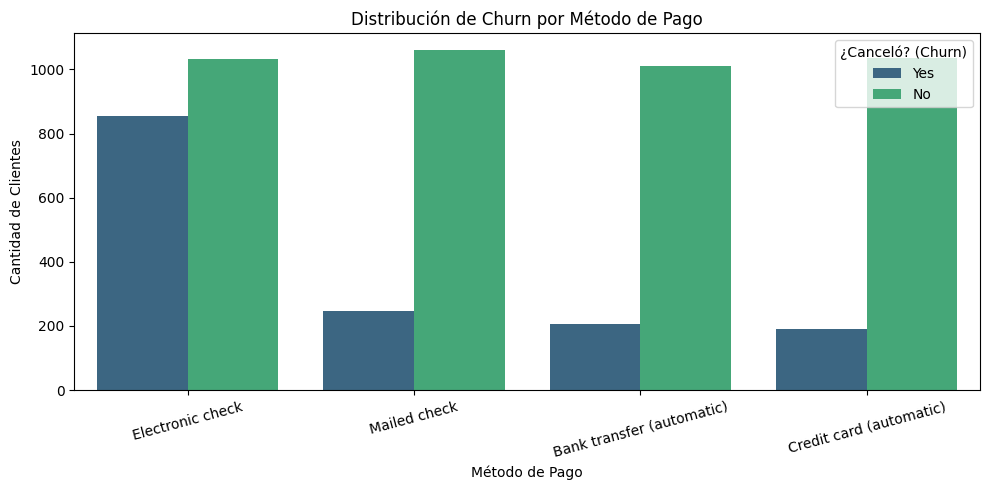

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.06,16.94
Credit card (automatic),84.57,15.43
Electronic check,54.69,45.31
Mailed check,81.24,18.76


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# /-- Churn por cada método de pago --/
plt.figure(figsize=(10, 5))
sns.countplot(data=datos, x='PaymentMethod', hue='Churn', palette='viridis')
plt.title('Distribución de Churn por Método de Pago')
plt.xlabel('Método de Pago')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=15)
plt.legend(title='¿Canceló? (Churn)')
plt.tight_layout()
plt.show()

tabla_frecuencia = pd.crosstab(datos['PaymentMethod'], datos['Churn'], normalize='index') * 100
display(tabla_frecuencia.round(2))